# Example 1: Symbolic Regressor

In [1]:
import sys
import os
from pathlib import Path

from numpy.core import records

# Add the parent folder (my_project) to Python's search path
sys.path.append(str(Path.cwd().parent))

%matplotlib inline
from gplearn.genetic_standard import SymbolicRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.random import check_random_state
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from collections import defaultdict
import ipywidgets as widgets
from IPython.display import HTML, display
from joblib import dump, load

os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

C:\Users\Khoo Zj\AppData\Local\Temp\ipykernel_36312\139672123.py:5: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.records.
  from numpy.core import records


In [2]:
def get_feature_map(function_set, n_features):
    """Creates a dictionary mapping every function name and feature index to a vector slot."""
    feature_map = {}
    idx = 0

    # 1. Map all function names (e.g., 'add', 'sub', 'mul')
    for func in function_set:
        feature_map[func.name] = idx
        idx += 1

    # 2. Map all feature indices (0, 1, 2, ... n_features - 1)
    for feat_idx in range(n_features):
        feature_map[feat_idx] = idx
        idx += 1

    # 3. Map Constant Bins
    constant_bins = [
        'CONST_Q0_To_Q1',  # c < min + 0.25 * range
        'CONST_Q1_To_Q2',  # min + 0.25 * range <= c < min + 0.50 * range
        'CONST_Q2_To_Q3',  # min + 0.50 * range A<= c < min + 0.75 * range
        'CONST_Q3_To_Q4'   # c >= min + 0.75 * range
    ]

    for bin_name in constant_bins:
        feature_map[bin_name] = idx
        idx += 1

    return feature_map

In [3]:
# Load the exact object back into memory
results = load('standard_results.joblib')
print(f"Loaded {len(results)} standard records successfully.")

Loaded 12 standard records successfully.


In [4]:
# Convert results into a DataFrame
def plot_r2_histogram():
    df_results = pd.DataFrame(results)

    # Display summary table with mean and standard deviation across seeds
    df_summary = df_results.groupby('Benchmark')['R2_Score'].agg(['mean', 'std']).reset_index()
    # print("\n--- Summary Performance across seeds ---")
    # print(df_summary)

    # Plot Bar Chart comparison across benchmarks with error bars (representing variability across seeds)
    plt.figure(figsize=(15, 5))
    sns.barplot(
        data=df_results,
        x='Benchmark',
        y='R2_Score',
        hue='Benchmark',
        palette='mako',
        errorbar='sd',       # Shows standard deviation across seeds
        capsize=0.1,         # Adds caps to error bars
        legend=False,
        edgecolor='black'
    )

    # Overlay individual seed points
    sns.stripplot(
        data=df_results,
        x='Benchmark',
        y='R2_Score',
        color='black',
        alpha=0.6,
        jitter=0.2,
        size=5
    )

    plt.axhline(0, color='red', linestyle='--', label='Baseline R2 = 0.0')
    plt.ylim(top=1, bottom=-1.0)
    plt.title('Test R2 Score Across Benchmarks (Mean +- SD over Random Seeds)', fontsize=12, fontweight='bold')
    plt.ylabel('R2 Score (Higher is Better)')
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [5]:
# Plot Best Program per Generation (R2 Score)

def plot_fitness():

    # 1. Group records by benchmark name directly from results
    benchmark_groups = defaultdict(list)
    for record in results:
        benchmark_groups[record["Benchmark"]].append(record)

    # 2. Set up subplots dynamically based on benchmark count
    n_benchmarks = len(benchmark_groups)
    rows = n_benchmarks // 3
    fig, axes = plt.subplots(rows, 3, figsize=(12, 4 * rows), sharey=True)
    axes = axes.flatten()

    # Iterate through each benchmark
    for idx, (b_name, records) in enumerate(benchmark_groups.items()):
        for record in records:
            seed = record["Seed"]
            r2_scores = record["R2 Score Per Gen"]
            ax = axes[idx]

            # Plot line for this specific seed
            ax.plot(
                range(len(r2_scores)),
                r2_scores,
                marker='o',
                markersize=0,
                linewidth=1.5,
                label=f'Seed {seed}',
                alpha=0.75
            )

            # Subplot formatting per benchmark
            ax.set_title(f'Benchmark: {b_name}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Generation')
            ax.set_ylabel('$R^2$ Score')
            # ax.set_ylim(-1.50, 1.50)  # Set limit on each axis object
            ax.grid(True, linestyle='--', alpha=0.2)
            ax.legend(loc='lower right', fontsize=8)

    # Hide any remaining unused subplots in the grid
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [6]:
# Plot Diversity Entropy vs Distance

def plot_diversity(line_alpha = 0.75):

    # 1. Group records by benchmark name directly from results
    benchmark_groups = defaultdict(list)
    for record in results:
        benchmark_groups[record["Benchmark"]].append(record)

    # 2. Set up subplots dynamically based on benchmark count
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(n_benchmarks, 2, figsize=(12, 6 * n_benchmarks), squeeze=False)

    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_diver_distance = axes[row_idx, 0]
        ax_diver_entropy = axes[row_idx, 1]

        for record in records:
            seed = record["Seed"]
            diver_distance = record["Diversity Distance"]
            diver_entropy = record["Diversity Entropy"]

            # Plot Diversity
            ax_diver_distance.plot(range(len(diver_distance)), diver_distance, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)
            ax_diver_entropy.plot(range(len(diver_entropy)), diver_entropy, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)

        # Formatting Left
        ax_diver_distance.set_title(f'{b_name} Diversity (Distance)', fontsize=11, fontweight='bold')
        ax_diver_distance.set_xlabel('Generation')
        ax_diver_distance.set_ylabel('Diversity (Distance)')
        ax_diver_distance.set_ylim(0, 1.05)
        ax_diver_distance.grid(True, linestyle='--', alpha=0.6)

        # Formatting Right
        ax_diver_entropy.set_title(f'{b_name} Diversity (Entropy)', fontsize=11, fontweight='bold')
        ax_diver_entropy.set_xlabel('Generation')
        ax_diver_entropy.set_ylabel(' Diversity (Entropy)')
        ax_diver_entropy.set_ylim(0, 1.05)
        ax_diver_entropy.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [7]:
# Plot Fitness vs Diversity (Distances)

def plot_solution_data(line_alpha = 0.75):

    # 1. Group records by benchmark name directly from results
    benchmark_groups = defaultdict(list)
    for record in results:
        benchmark_groups[record["Benchmark"]].append(record)

    # 2. Set up subplots dynamically based on benchmark count
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(n_benchmarks, 3, figsize=(18, 6 * n_benchmarks), squeeze=False)

    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_r2 = axes[row_idx, 0]
        ax_diver_distance = axes[row_idx, 1]
        ax_diver_entropy = axes[row_idx, 2]

        for record in records:
            seed = record["Seed"]
            fitness = record["R2 Score Per Gen"]
            diversity_distance = record["Diversity Distance"]
            diversity_entropy = record['Diversity Entropy']

            # Plot R2 Score on Left Subplot
            ax_r2.plot(
                range(len(fitness)),
                fitness,
                linewidth=1.5,
                label=f"Seed {seed}",
                alpha= line_alpha,
            )

            ax_diver_distance.plot(
                range(len(diversity_distance)),
                diversity_distance,
                linewidth=1.5,
                label=f'Seed {seed}',
                alpha= line_alpha
            )

            ax_diver_entropy.plot(
                range(len(diversity_entropy)),
                diversity_entropy,
                linewidth=1.5,
                label=f'Seed {seed}',
                alpha= line_alpha
            )

        # Formatting Left (R2 Score)
        ax_r2.set_title(
            f"{b_name} $R^2$ Score Progress", fontsize=11, fontweight="bold"
        )
        ax_r2.set_xlabel("Generation")
        ax_r2.set_ylabel("$R^2$ Score")
        ax_r2.set_ylim(-1, 1.05)
        ax_r2.grid(True, linestyle="--", alpha=0.6)
        ax_r2.legend(loc="lower right")

        # Formatting Middle (Diversity Distance)
        ax_diver_distance.set_title(f'{b_name} Diversity (Distance)', fontsize=11, fontweight='bold')
        ax_diver_distance.set_xlabel('Generation')
        ax_diver_distance.set_ylabel('Diversity (Distance)')
        ax_diver_distance.set_ylim(0, 1.05)
        ax_diver_distance.grid(True, linestyle='--', alpha=0.6)

        # Formatting Left
        ax_diver_entropy.set_title(f'{b_name} Diversity (Entropy)', fontsize=11, fontweight='bold')
        ax_diver_entropy.set_xlabel('Generation')
        ax_diver_entropy.set_ylabel('Diversity (Entropy)')
        ax_diver_entropy.set_ylim(0, 1.05)
        ax_diver_entropy.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [8]:
def plot_entropy_heatmaps(line_alpha=0.75):
    """Plots side-by-side R2 progression line chart (Left) and Entropy Heatmap (Right)

    for each seed, grouped sequentially by Benchmark (All Seed A, then All Seed B, etc.).
    """
    # 1. Get unique benchmarks in order of appearance
    benchmarks = list(dict.fromkeys(res['Benchmark'] for res in results))

    # 2. Loop through each benchmark completely before moving to the next
    for b_name in benchmarks:
        # Filter all seed records matching the current benchmark
        benchmark_results = [
            res for res in results if res['Benchmark'] == b_name
        ]

        for res in benchmark_results:
            seed = res['Seed']
            name = res['Benchmark']
            fitness = res['R2 Score Per Gen']

            # Extract feature map directly from this record
            feature_map = res['Feature Map']

            # Build Y-axis labels sorted by column index
            labels = [None] * len(feature_map)
            for key, idx in feature_map.items():
                labels[idx] = str(key)

            entropy_history = np.array(res['Entropy History'])

            if entropy_history.size == 0:
                print(f'Skipping {name} (Seed {seed}): Empty entropy history.')
                continue

            # sharey=False is critical because R2 score (-1 to 1) and Heatmap loci are different axes
            fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

            # 1. Plot R2 Score Progression on Left Subplot
            ax_r2 = axes[0]
            ax_r2.plot(
                range(len(fitness)),
                fitness,
                linewidth=1.5,
                label=f'Seed {seed}',
                alpha=line_alpha,
                color='tab:red',
            )

            ax_r2.set_title(
                f'$R^2$ Score Progress\n(Seed: {seed} | Benchmark: {name})',
                fontsize=12,
            )
            ax_r2.set_xlabel('Generation', fontsize=10)
            ax_r2.set_ylabel('$R^2$ Score', fontsize=10)
            ax_r2.set_ylim(-1.0, 1.05)
            ax_r2.grid(True, linestyle='--', alpha=0.6)
            ax_r2.legend(loc='lower right')

            # 2. Entropy Heatmap on Right Subplot
            ax_heat = axes[1]
            sns.heatmap(
                entropy_history.T,
                ax=ax_heat,
                cmap='viridis',
                yticklabels=labels,
                cbar_kws={'label': 'Shannon Entropy (bits)'},
                vmin=0.0,
            )
            ax_heat.set_title(
                f'Locus Entropy\n(Seed: {seed} | Benchmark: {name})',
                fontsize=12,
            )
            ax_heat.set_xlabel('Generation', fontsize=10)
            ax_heat.set_ylabel('Feature / Locus', fontsize=10)

            # Adjust X-ticks readability for both subplots
            n_gens = len(fitness)
            step = max(1, n_gens // 10)
            x_ticks = np.arange(0, n_gens, step)

            ax_r2.set_xticks(x_ticks)
            ax_r2.set_xticklabels(x_ticks)

            ax_heat.set_xticks(
                x_ticks + 0.5
            )  # +0.5 aligns ticks to center of heatmap columns
            ax_heat.set_xticklabels(x_ticks, rotation=0)

            plt.suptitle(
                f'Co-Evolutionary Performance & Diversity Analysis - {name} | seed {seed}',
                fontsize=14,
                fontweight='bold',
            )
            plt.tight_layout()
            plt.show()

In [9]:
def plot_entropy_heatmaps_tabs(line_alpha=0.75):
    """Creates a tabbed session interface where each Benchmark has its own tab containing all its seed plots."""
    benchmarks = list(dict.fromkeys(res['Benchmark'] for res in results))
    tab = widgets.Tab()
    tab_outputs = []

    for b_name in benchmarks:
        out = widgets.Output()
        benchmark_results = [
            res for res in results if res['Benchmark'] == b_name
        ]

        with out:
            for res in benchmark_results:
                seed = res['Seed']
                name = res['Benchmark']
                fitness = res['R2 Score Per Gen']
                feature_map = res['Feature Map']

                labels = [None] * len(feature_map)
                for key, idx in feature_map.items():
                    labels[idx] = str(key)

                entropy_history = np.array(res['Entropy History'])

                if entropy_history.size == 0:
                    continue

                fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

                # Left: R2 Plot
                axes[0].plot(
                    range(len(fitness)),
                    fitness,
                    linewidth=1.5,
                    color='tab:orange',
                    label=f'Seed {seed}',
                    alpha=line_alpha,
                )
                axes[0].set_title(
                    f'$R^2$ Score Progress\n(Seed: {seed} | Benchmark: {name})',
                    fontsize=11,
                )
                axes[0].set_xlabel('Generation')
                axes[0].set_ylabel('$R^2$ Score')
                axes[0].set_ylim(-1.0, 1.05)
                axes[0].grid(True, linestyle='--', alpha=0.6)

                # Right: Heatmap
                sns.heatmap(
                    entropy_history.T,
                    ax=axes[1],
                    cmap='viridis',
                    yticklabels=labels,
                    cbar_kws={'label': 'Entropy (bits)'},
                    vmin=0.0,
                )
                axes[1].set_title(
                    f'Locus Entropy\n(Seed: {seed} | Benchmark: {name})',
                )
                axes[1].set_xlabel('Generation')

                n_gens = len(fitness)
                step = max(1, n_gens // 10)
                x_ticks = np.arange(0, n_gens, step)
                axes[0].set_xticks(x_ticks)
                axes[1].set_xticks(x_ticks + 0.5)
                axes[1].set_xticklabels(x_ticks, rotation=0)

                plt.tight_layout()
                plt.show()

        tab_outputs.append(out)

    tab.children = tab_outputs
    for i, name in enumerate(benchmarks):
        tab.set_title(i, f'{name}')
        tab.add_class("custom-tab-font")


    styling = HTML("""
        <style>
        .custom-tab-font .lm-TabBar-tabLabel,
        .custom-tab-font .p-TabBar-tabLabel {
            font-size: 8px !important;
        }
        </style>
        """)

    display(styling, tab)


# Usage:
# plot_experiment_entropy_heatmaps_tabs(results)

In [10]:
def plot_entropy_heatmaps_sessions(line_alpha=0.75):
    """Groups plots by Benchmark into collapsible HTML section sessions."""
    benchmarks = list(dict.fromkeys(res['Benchmark'] for res in results))

    for b_name in benchmarks:
        benchmark_results = [
            res for res in results if res['Benchmark'] == b_name
        ]

        # 1. Display Session Banner
        banner_html = f"""
        <div style="background-color: #2b3e50; padding: 12px 20px; margin: 25px 0 15px 0; border-radius: 6px;">
            <h2 style="color: #ffffff; margin: 0; font-family: sans-serif;">
                SESSION: Benchmark <span style="color: #00d1b2;">{b_name}</span>
                <span style="font-size: 14px; color: #a0aec0; font-weight: normal;">({len(benchmark_results)} Seeds)</span>
            </h2>
        </div>
        """
        display(HTML(banner_html))

        # 2. Iterate through all seeds for this benchmark
        for res in benchmark_results:
            seed = res['Seed']
            name = res['Benchmark']
            fitness = res['R2 Score Per Gen']
            feature_map = res['Feature Map']

            labels = [None] * len(feature_map)
            for key, idx in feature_map.items():
                labels[idx] = str(key)

            entropy_history = np.array(res['Entropy History'])

            if entropy_history.size == 0:
                print(f'Skipping {name} (Seed {seed}): Empty entropy history.')
                continue

            fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

            # Left Subplot: R2 Progression
            ax_r2 = axes[0]
            ax_r2.plot(
                range(len(fitness)),
                fitness,
                linewidth=1.5,
                label=f'Seed {seed}',
                alpha=line_alpha,
                color='tab:orange',
            )
            ax_r2.set_title(
                f'$R^2$ Score Progress\n(Seed: {seed} | Benchmark: {name})',
                fontsize=12,
            )
            ax_r2.set_xlabel('Generation', fontsize=10)
            ax_r2.set_ylabel('$R^2$ Score', fontsize=10)
            ax_r2.set_ylim(-1.0, 1.05)
            ax_r2.grid(True, linestyle='--', alpha=0.6)
            ax_r2.legend(loc='lower right')

            # Right Subplot: Locus Entropy Heatmap
            ax_heat = axes[1]
            sns.heatmap(
                entropy_history.T,
                ax=ax_heat,
                cmap='viridis',
                yticklabels=labels,
                cbar_kws={'label': 'Shannon Entropy (bits)'},
                vmin=0.0,
            )
            ax_heat.set_title(
                f'Locus Entropy\n(Seed: {seed} | Benchmark: {name})',
                fontsize=12,
            )
            ax_heat.set_xlabel('Generation', fontsize=10)
            ax_heat.set_ylabel('Feature / Locus', fontsize=10)

            n_gens = len(fitness)
            step = max(1, n_gens // 10)
            x_ticks = np.arange(0, n_gens, step)

            ax_r2.set_xticks(x_ticks)
            ax_r2.set_xticklabels(x_ticks)
            ax_heat.set_xticks(x_ticks + 0.5)
            ax_heat.set_xticklabels(x_ticks, rotation=0)

            plt.tight_layout()
            plt.show()

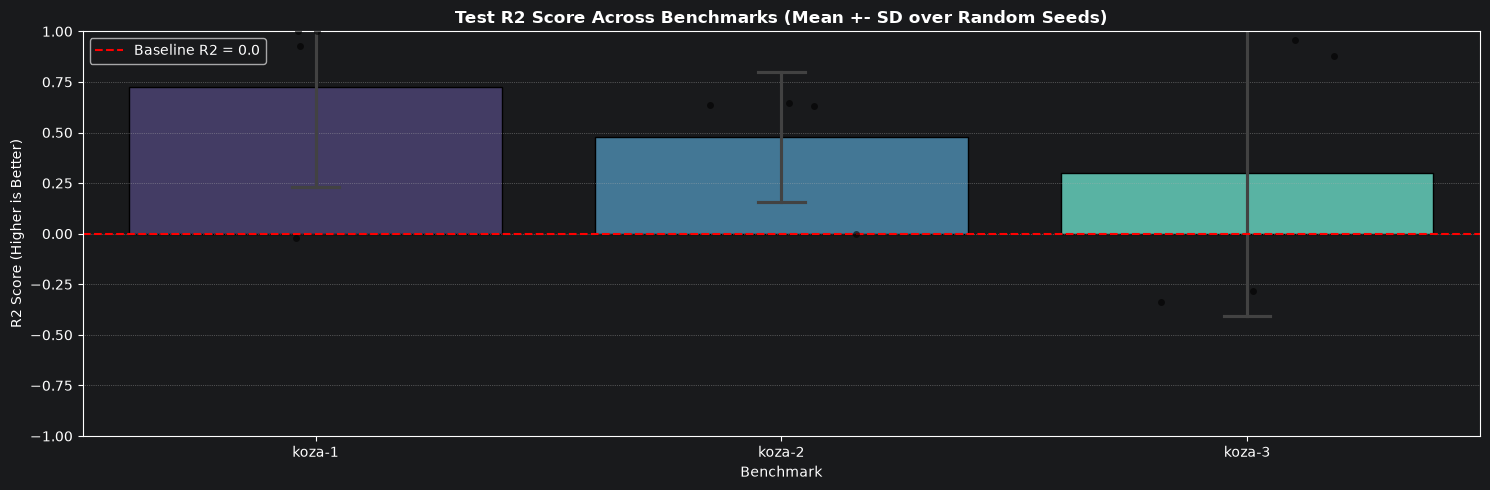

In [11]:
plot_r2_histogram()

In [12]:
plot_entropy_heatmaps_tabs()

# plot_r2_histogram()
# plot_fitness()
# plot_entropy_heatmaps_sessions()
# plot_diversity()
# plot_solution_data()